## PREGUNTA DE NEGOCIO SEMANA 3

<b>¿Hay una relación entre el precio del alojamiento y la satisfacción general de los clientes? ¿Cómo varía esta relación entre las ciudades?</b>

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import pearsonr, spearmanr
import numpy as np
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns',  40)

In [99]:
df = pd.read_csv('tourist_accommodation_10112025_clean_2.csv')
df.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,is_valid,ocupacion_mes
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",400.0,3,365,True,7,20,40,130,78,2010-02-01,2017-05-09,97.0,10.0,10.0,10.0,10.0,10.0,10.0,0,0.406039,Spain,Málaga,2018-07-31,True,23
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,Cármenes,Latina,Private room,1,1,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",170.0,4,40,True,0,0,0,162,33,2014-10-10,NaN,92.0,9.0,9.0,10.0,10.0,8.0,9.0,0,0.244384,Spain,Madrid,2020-01-10,True,30
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2.0,2.0,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",990.0,2,120,True,26,31,31,270,148,2011-05-01,NaN,98.0,10.0,10.0,10.0,10.0,10.0,10.0,1,0.836316,Spain,Sevilla,2019-07-29,True,4
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,L'Antiga Esquerra De L'Eixample,Eixample,Private room,2,2,1.0,1.0,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",400.0,2,730,True,9,23,49,300,292,NaN,2020-04-01,94.0,10.0,9.0,10.0,10.0,10.0,9.0,1,4.271087,Spain,Barcelona,2020-01-10,True,21
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1,2.0,5.0,"Wifi,Pool,Free parking on premises,Breakfast,P...",900.0,1,180,True,0,19,49,312,36,2011-08-07,2018-08-08,97.0,10.0,10.0,10.0,10.0,10.0,10.0,0,0.207254,Spain,Girona,2019-02-19,True,30


In [100]:
# Eliminar filas con nulos
df_clean = df.dropna(subset=['price', 'review_scores_rating', 'city'])

## Distribución de rating por precio

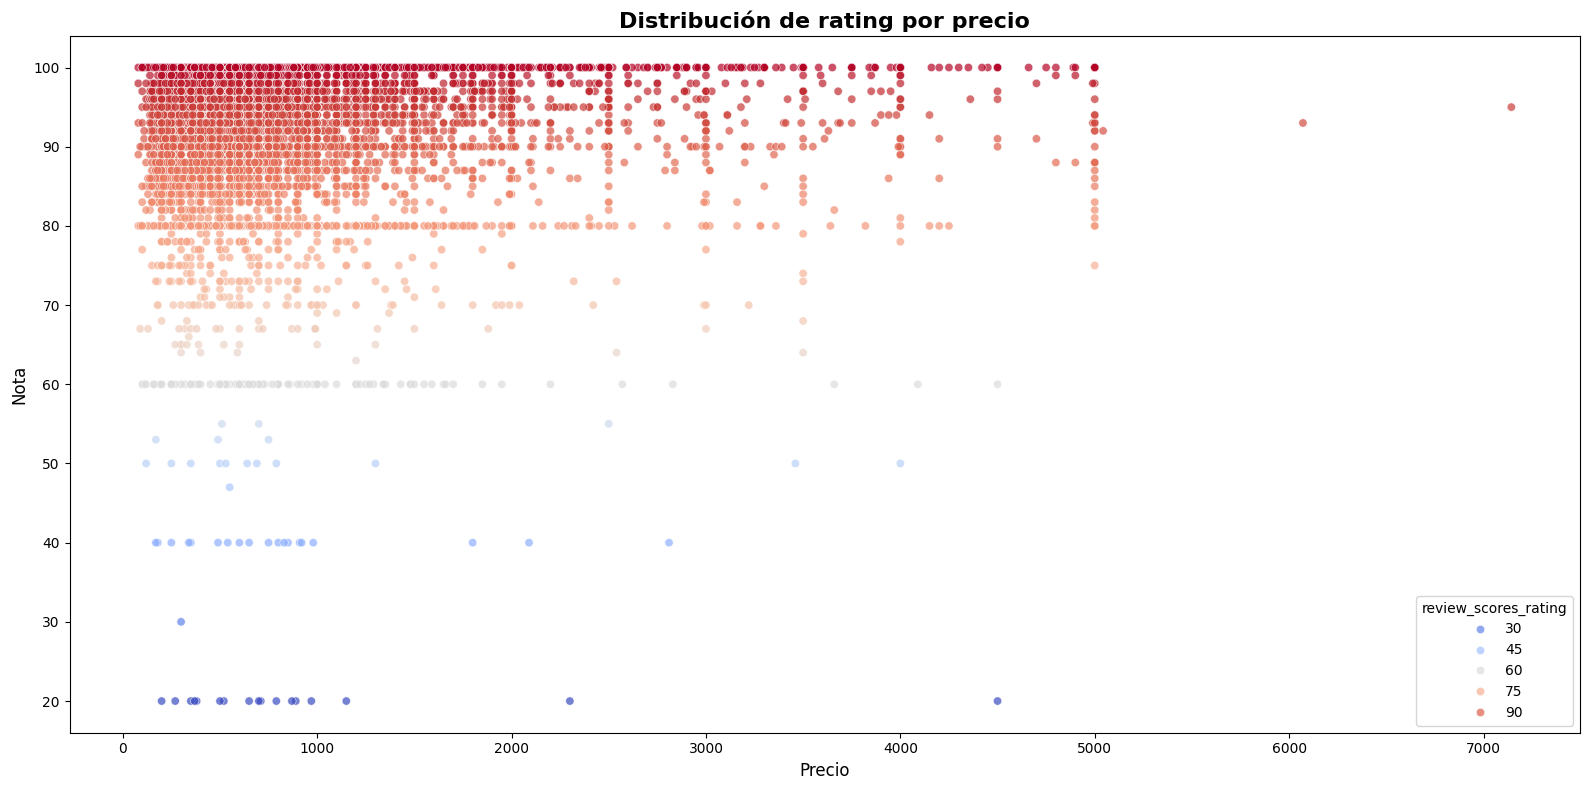

In [101]:
plt.figure(figsize=(16, 8))
sns.scatterplot(
    data=df_clean,
    x='price',
    y='review_scores_rating',
    hue='review_scores_rating',
    palette='coolwarm',
    alpha=0.7,
    sizes=(10, 200)
)
plt.title("Distribución de rating por precio", fontsize=16, weight='bold')
plt.xlabel("Precio", fontsize=12)
plt.ylabel("Nota", fontsize=12)
plt.tight_layout()
plt.show()


## Distribución de precios por ciudad

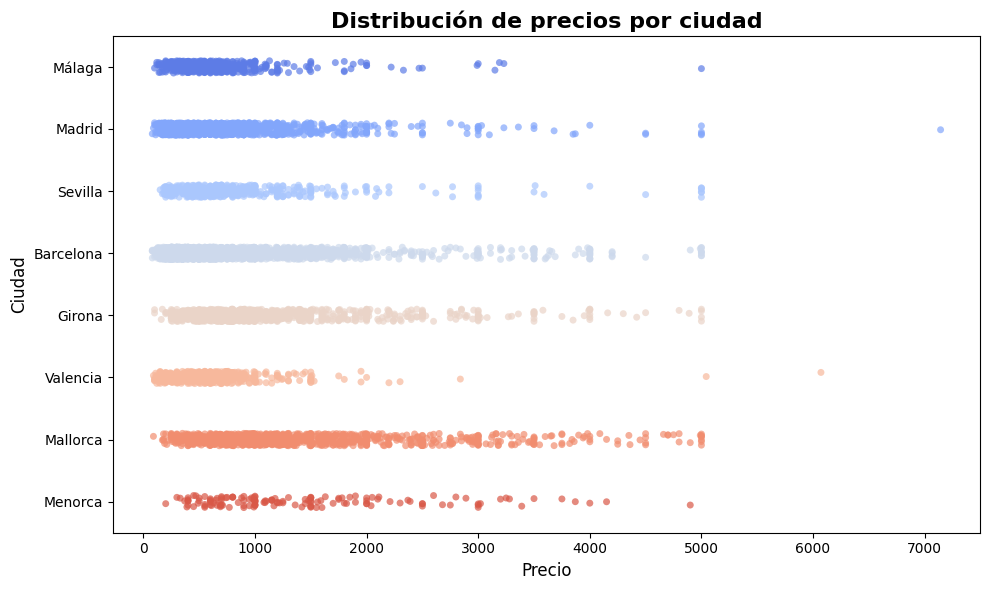

In [102]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=df_clean,
    x='price',
    y='city',
    jitter=True,
    alpha=0.7,
    palette='coolwarm'
)
plt.title("Distribución de precios por ciudad", fontsize=16, weight='bold')
plt.xlabel("Precio", fontsize=12),
plt.ylabel("Ciudad", fontsize=12),
plt.tight_layout()
plt.show()

## Distribución de rating por ciudad

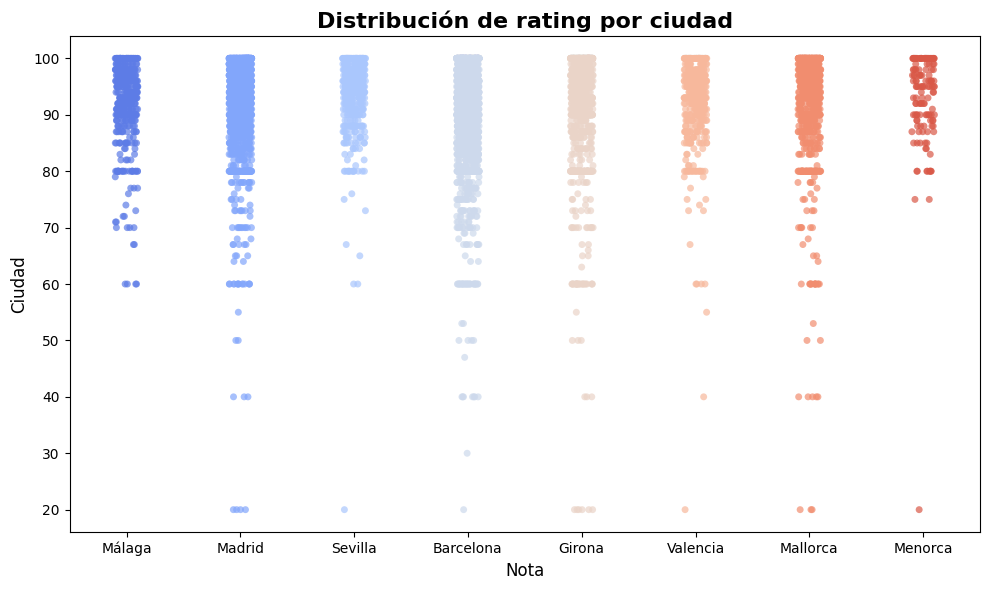

In [103]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=df_clean,
    x='city',
    y='review_scores_rating',
    jitter=True,
    alpha=0.7,
    palette='coolwarm'
)
plt.title("Distribución de rating por ciudad", fontsize=16, weight='bold')
plt.xlabel("Nota", fontsize=12),
plt.ylabel("Ciudad", fontsize=12),
plt.tight_layout()
plt.show()

## Test de Shapiro

In [104]:
shapiro_price = shapiro(df_clean['price'].sample(5000, random_state=42))
shapiro_rating = shapiro(df_clean['review_scores_rating'].sample(5000, random_state=42))

print("Shapiro-Wilk para 'price':   W = %.3f, p = %.2f" % shapiro_price)
print("Shapiro-Wilk para 'rating':  W = %.3f, p = %.2f" % shapiro_rating)

Shapiro-Wilk para 'price':   W = 0.756, p = 0.00
Shapiro-Wilk para 'rating':  W = 0.767, p = 0.00


Ambos p-valores son prácticamente 0, lo que significa que tanto price como rating no siguen una distribución normal.
Spearman (rangos, no requiere normalidad) es más apropiado para nuestros datos.

## Test de Pearson y Spearman

In [105]:
# Pearson
pearson_corr, pearson_p = pearsonr(df_clean['price'], df_clean['review_scores_rating'])

# Spearman
spearman_corr, spearman_p = spearmanr(df_clean['price'], df_clean['review_scores_rating'])

print(f"Correlación de Pearson: {pearson_corr:.3f} (p={pearson_p:.4f})")
print(f"Correlación de Spearman: {spearman_corr:.3f} (p={spearman_p:.4f})")


Correlación de Pearson: 0.045 (p=0.0002)
Correlación de Spearman: 0.088 (p=0.0000)


- Sugiere que no hay una relación monótona fuerte entre el precio y la puntuación.
- La fuerza de la relación es mínima.   

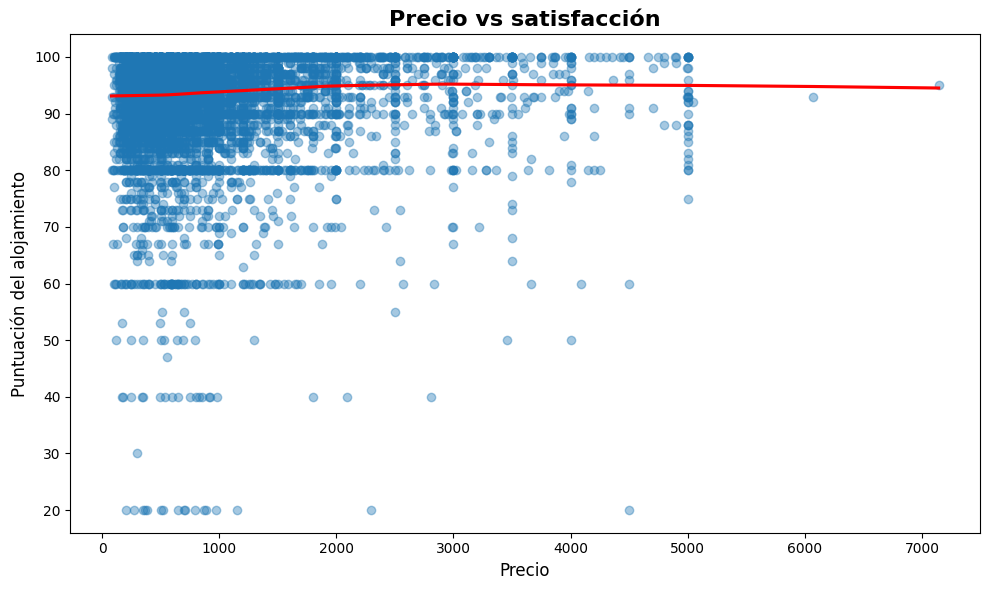

In [106]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df_clean,
    x='price',
    y='review_scores_rating',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'},
    lowess=True
)
plt.title("Precio vs satisfacción", fontsize=16, weight='bold')
plt.xlabel("Precio", fontsize=12)
plt.ylabel("Puntuación del alojamiento", fontsize=12)
plt.tight_layout()
plt.show()


Hay mucha dispersión: los puntos están bastante alejados de la línea, lo que indica que el precio no explica bien la variación en las puntuaciones. No hay una relación clara entre pagar más y recibir mejor satisfacción.

Ni los precios ni las puntuaciones de satisfacción siguen una distribución normal, lo que viola el supuesto de normalidad de Pearson.
Esto ya justifica que Spearman sea más apropiado para analizar la relación entre precio y rating.


-> Ambos coeficientes son muy bajos, por lo que se observa una relación muy débil entre precio y rating.
El hecho de que Spearman > Pearson sugiere que la relación puede ser monótona pero no estrictamente lineal — es decir, quizás los precios más altos tienden a ratings algo mejores, pero no en proporción constante.

Conclusión global:

No hay una relación lineal fuerte entre el precio y la satisfacción general. Los huéspedes no parecen valorar más (ni menos) los alojamientos por ser más caros, al menos de forma directa.

Aunque los precios varían mucho entre ciudades y alojamientos, las puntuaciones de los huéspedes se mantienen altas en casi todos los casos. Esto sugiere que el precio no es un factor determinante en la satisfacción, y que otros aspectos (como limpieza, ubicación o atención del anfitrión) pueden ser más importantes.

## Test de Shapiro:

In [107]:
results_norm = []

for city, g in df_clean.groupby('city'):
    if len(g) > 10:  
        sample_price = g['price'].sample(5000, random_state=42) if len(g) > 5000 else g['price']
        sample_rating = g['review_scores_rating'].sample(5000, random_state=42) if len(g) > 5000 else g['review_scores_rating']

        w_price, p_price = shapiro(sample_price)
        w_rating, p_rating = shapiro(sample_rating)

        results_norm.append({
        'city': city,
        'shapiro_price_W': round(w_price, 3),
        'shapiro_price_p': round(p_price, 3),
        'shapiro_rating_W': round(w_rating, 3),
        'shapiro_rating_p': round(p_rating, 3)
    })
        

shapiro_df = pd.DataFrame(results_norm).set_index('city')
print(shapiro_df)



           shapiro_price_W  shapiro_price_p  shapiro_rating_W  \
city                                                            
Barcelona            0.728              0.0             0.831   
Girona               0.792              0.0             0.732   
Madrid               0.726              0.0             0.739   
Mallorca             0.877              0.0             0.689   
Menorca              0.889              0.0             0.658   
Málaga               0.724              0.0             0.852   
Sevilla              0.679              0.0             0.736   
Valencia             0.666              0.0             0.745   

           shapiro_rating_p  
city                         
Barcelona               0.0  
Girona                  0.0  
Madrid                  0.0  
Mallorca                0.0  
Menorca                 0.0  
Málaga                  0.0  
Sevilla                 0.0  
Valencia                0.0  


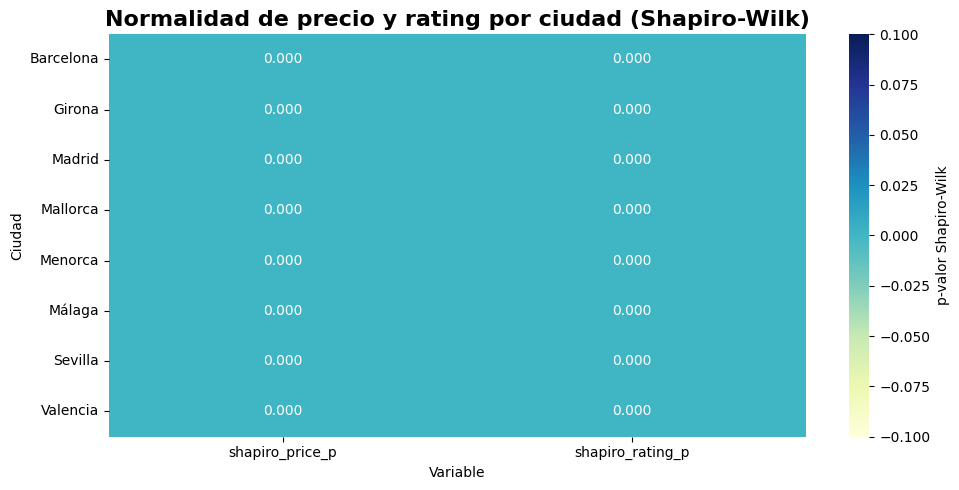

In [121]:
plt.figure(figsize=(10,5))
sns.heatmap(
    shapiro_df[['shapiro_price_p','shapiro_rating_p']], 
    annot=True, fmt=".3f", cmap="YlGnBu", 
    cbar_kws={'label': 'p-valor Shapiro-Wilk'}
)
plt.title("Normalidad de precio y rating por ciudad (Shapiro-Wilk)", fontsize=16, weight='bold')
plt.xlabel("Variable")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()


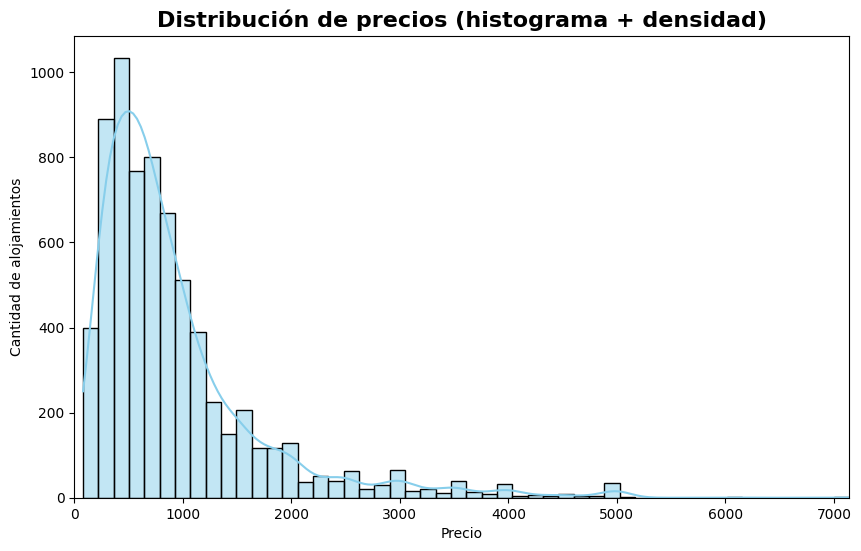

In [109]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean['price'].dropna(), bins=50, kde=True, color='skyblue')
plt.title("Distribución de precios (histograma + densidad)", fontsize=16, weight='bold')
plt.xlabel("Precio")
plt.ylabel("Cantidad de alojamientos")
plt.xlim(0, df_clean['price'].quantile(1)) 
plt.show()


En general, price tiene una cola larga hacia la derecha (asimetría positiva): la mayoría de los precios están concentrados en valores bajos o medios, pero hay algunos precios muy altos que "estiran" la distribución hacia la derecha.

Los valores de W (entre 0.66 y 0.89) están bastante lejos de 1, lo que refuerza la idea de que las distribuciones de price y review_scores_rating no son normales.

review_scores_rating suele estar sesgado hacia valores altos (la mayoría de los alojamientos tienen buenos ratings, con pocos ratings bajos).

Debemos basar interpretaciones en la correlación de Spearman, no en Pearson.
Spearman es robusto ante asimetrías y detecta la relación monótona ascendente (ligeramente curvada) que se ve en gráficos con lowess = true.

## Correlación de Spearman

In [110]:
results = []

for city, g in df_clean.groupby('city'):
    if len(g) > 2:  # al menos 3 datos para calcular
        spearman_corr, spearman_p = spearmanr(g['price'], g['review_scores_rating'])

        results.append({
            'city': city,
            'spearman_corr': round(spearman_corr, 3),
            'spearman_p': round(spearman_p, 3)
        })

corr_tests = pd.DataFrame(results).set_index('city')
print(corr_tests)

           spearman_corr  spearman_p
city                                
Barcelona         -0.056       0.011
Girona             0.181       0.000
Madrid             0.071       0.004
Mallorca           0.197       0.000
Menorca            0.085       0.319
Málaga             0.159       0.001
Sevilla            0.079       0.103
Valencia           0.084       0.085


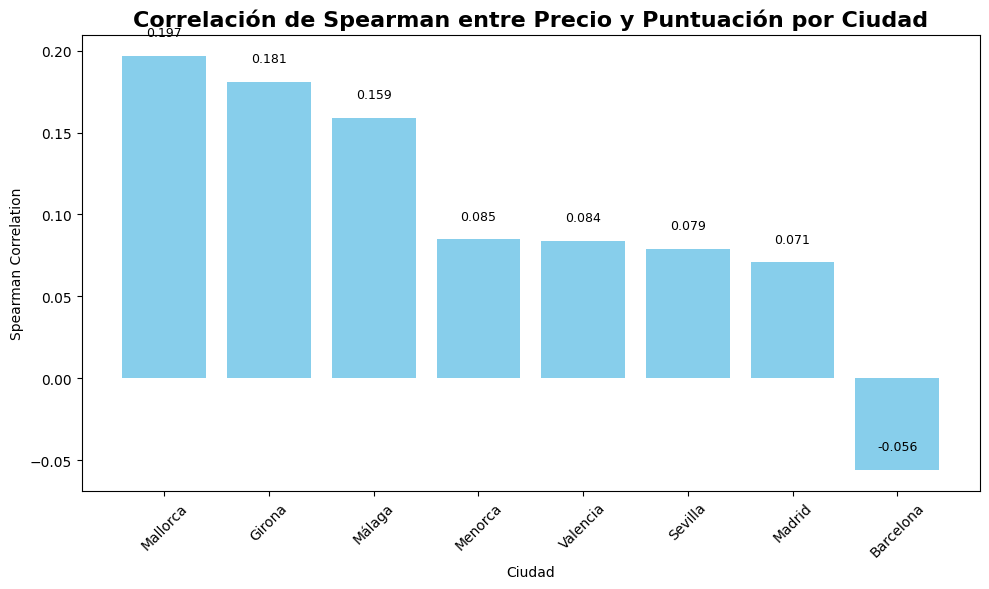

In [122]:
# Ordenar por correlación Spearman de mayor a menor
corr_sorted = corr_tests.sort_values(by='spearman_corr', ascending=False)

# Crear gráfico de barras
plt.figure(figsize=(10,6))
bars = plt.bar(corr_sorted.index, corr_sorted['spearman_corr'], color='skyblue')

# Añadir etiquetas con el valor en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.3f}", ha='center', va='bottom', fontsize=9)

# Título y etiquetas
plt.title("Correlación de Spearman entre Precio y Puntuación por Ciudad", fontsize=16, weight='bold')
plt.ylabel("Spearman Correlation")
plt.xlabel("Ciudad")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Girona, Mallorca, Málaga, Correlación débil pero positiva, significativa. Precios más altos tienden a tener ligeramente mejor rating.

Menorca: Correlación débil y no significativa. No hay evidencia de relación.

Madrid, Sevilla, Valencia: Correlación muy débil positiva, significativa pero poco relevante.

Barcelona: relación negativa.

En todas, la magnitud de la correlación (< 0.15) indica que el precio explica menos del 2% de la variabilidad en la satisfacción (porque 𝑟2 ≈ 0.02).

En general, la relación precio ↔ rating es muy débil.

## Correlación precio y satisfacción por ciudad

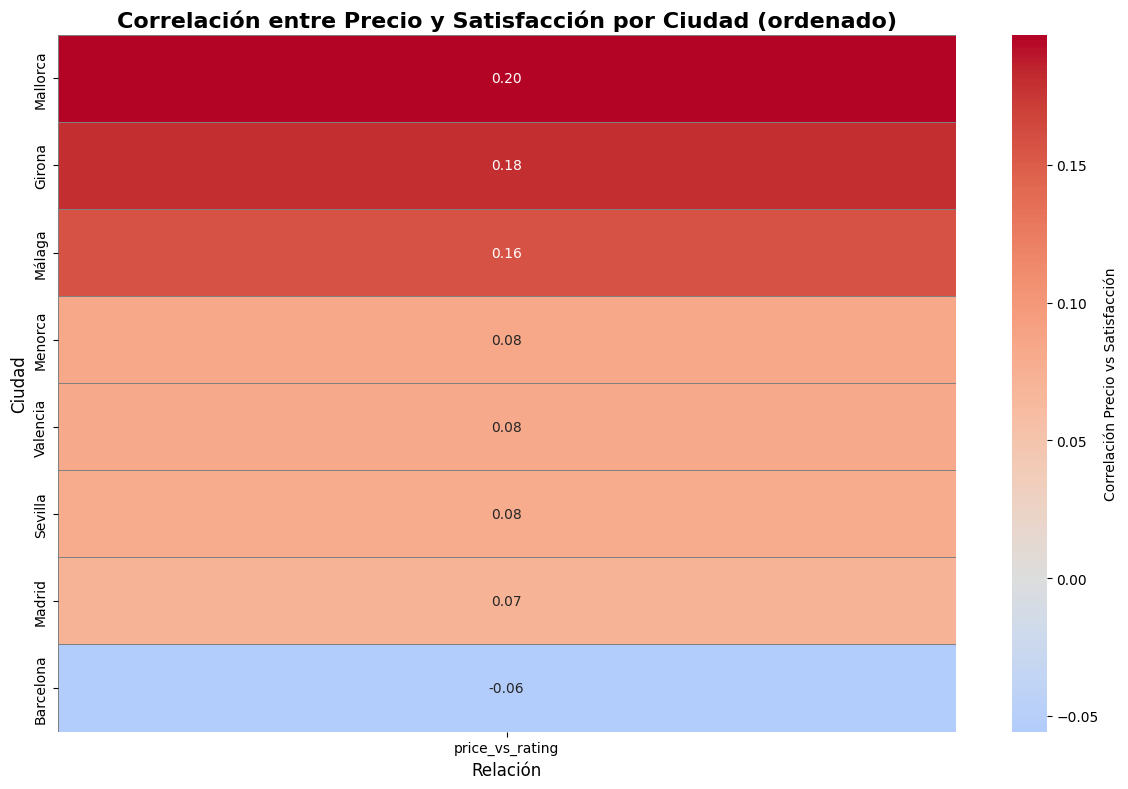

In [132]:
# Ordenar las ciudades por correlación (de mayor a menor)
corr_sorted = corr_df.sort_values(by='price_vs_rating', ascending=False)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_sorted,   # usamos el DataFrame ya ordenado
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Correlación Precio vs Satisfacción'}
)

plt.title("Correlación entre Precio y Satisfacción por Ciudad (ordenado)", fontsize=16, weight='bold')
plt.xlabel("Relación", fontsize=12)
plt.ylabel("Ciudad", fontsize=12)
plt.tight_layout()
plt.show()

## Métricas por ciudad

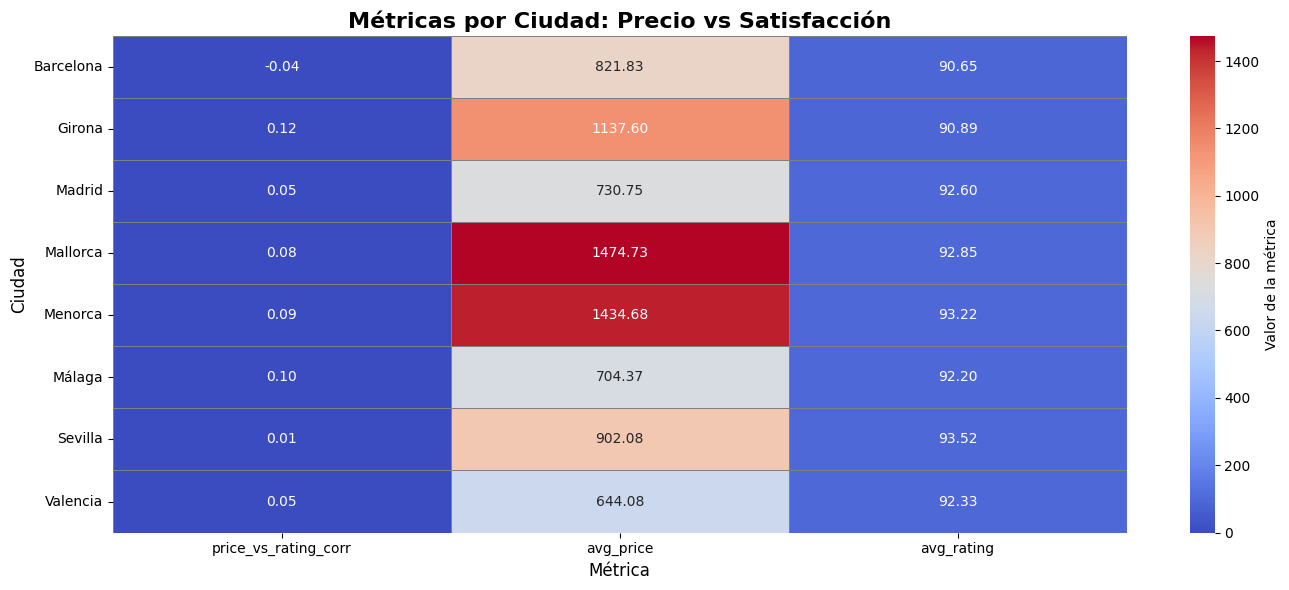

In [114]:
metrics = []

for city, g in df_clean.groupby('city'):
    if len(g) > 1:  # mínimo 2 datos para correlación
        corr = g[['price', 'review_scores_rating']].corr().iloc[0,1]
        avg_price = g['price'].mean()
        avg_rating = g['review_scores_rating'].mean()
        count = len(g)
        metrics.append({
            'city': city,
            'price_vs_rating_corr': corr,
            'avg_price': avg_price,
            'avg_rating': avg_rating
        })

metrics_df = pd.DataFrame(metrics).set_index('city')

# Heatmap con varias métricas
plt.figure(figsize=(14, len(metrics_df)*0.5 + 2))
sns.heatmap(
    metrics_df, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    linewidths=0.5, 
    linecolor='gray',
    cbar_kws={'label': 'Valor de la métrica'}
)

plt.title("Métricas por Ciudad: Precio vs Satisfacción", fontsize=16, weight='bold')
plt.xlabel("Métrica", fontsize=12)
plt.ylabel("Ciudad", fontsize=12)
plt.tight_layout()
plt.show()


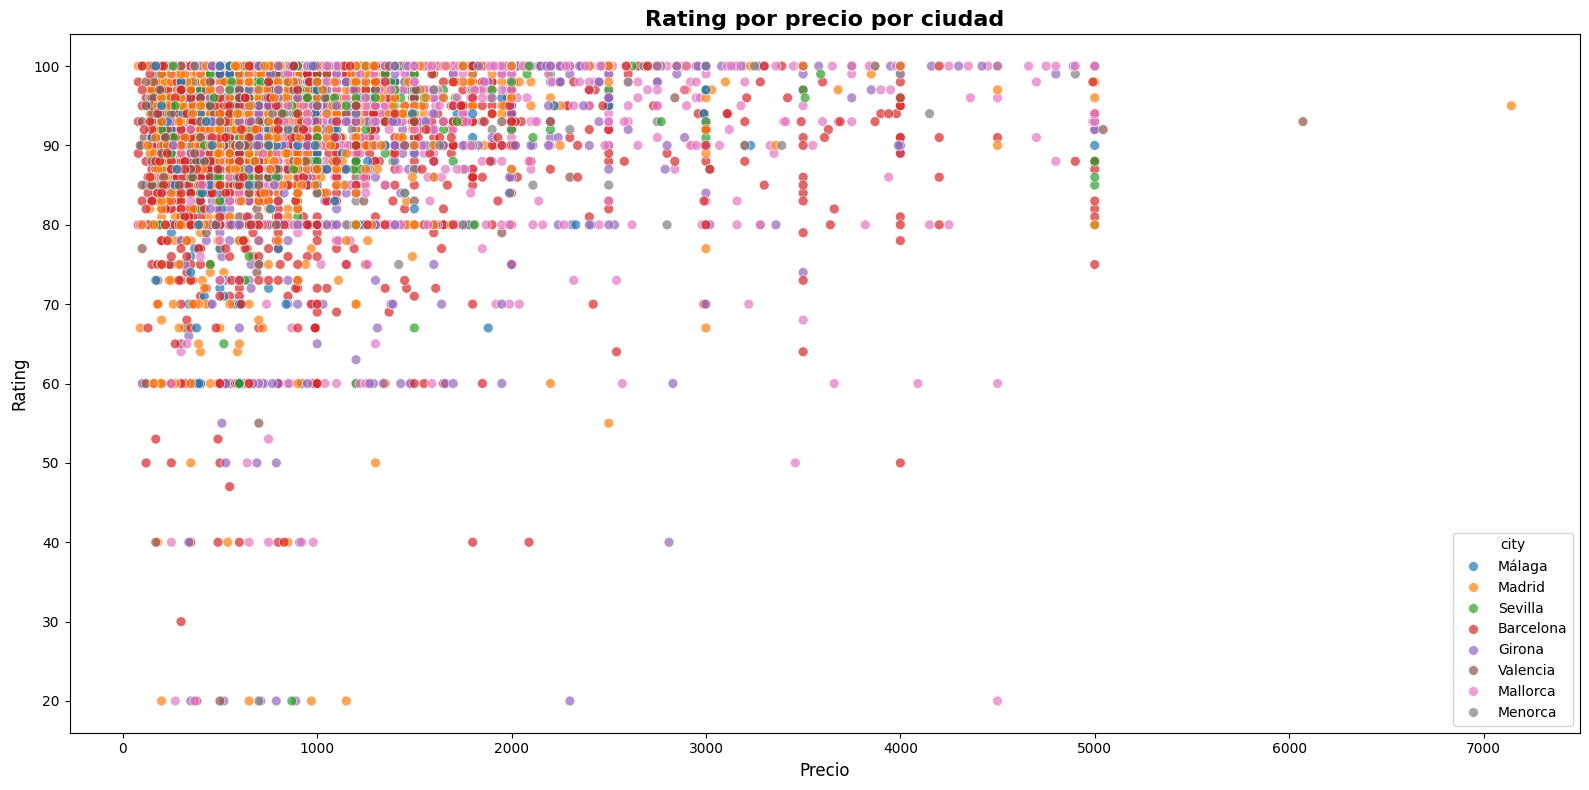

In [115]:
plt.figure(figsize=(16, 8))
sns.scatterplot(
    data=df_clean,
    x='price',
    y='review_scores_rating',
    hue='city',     
    alpha=0.7,       # transparencia para ver puntos superpuestos
    palette='tab10', 
    s=50             
)
plt.title("Rating por precio por ciudad", fontsize=16, weight='bold')
plt.xlabel("Precio", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.tight_layout()
plt.show()

## Facetgrid por ciudades

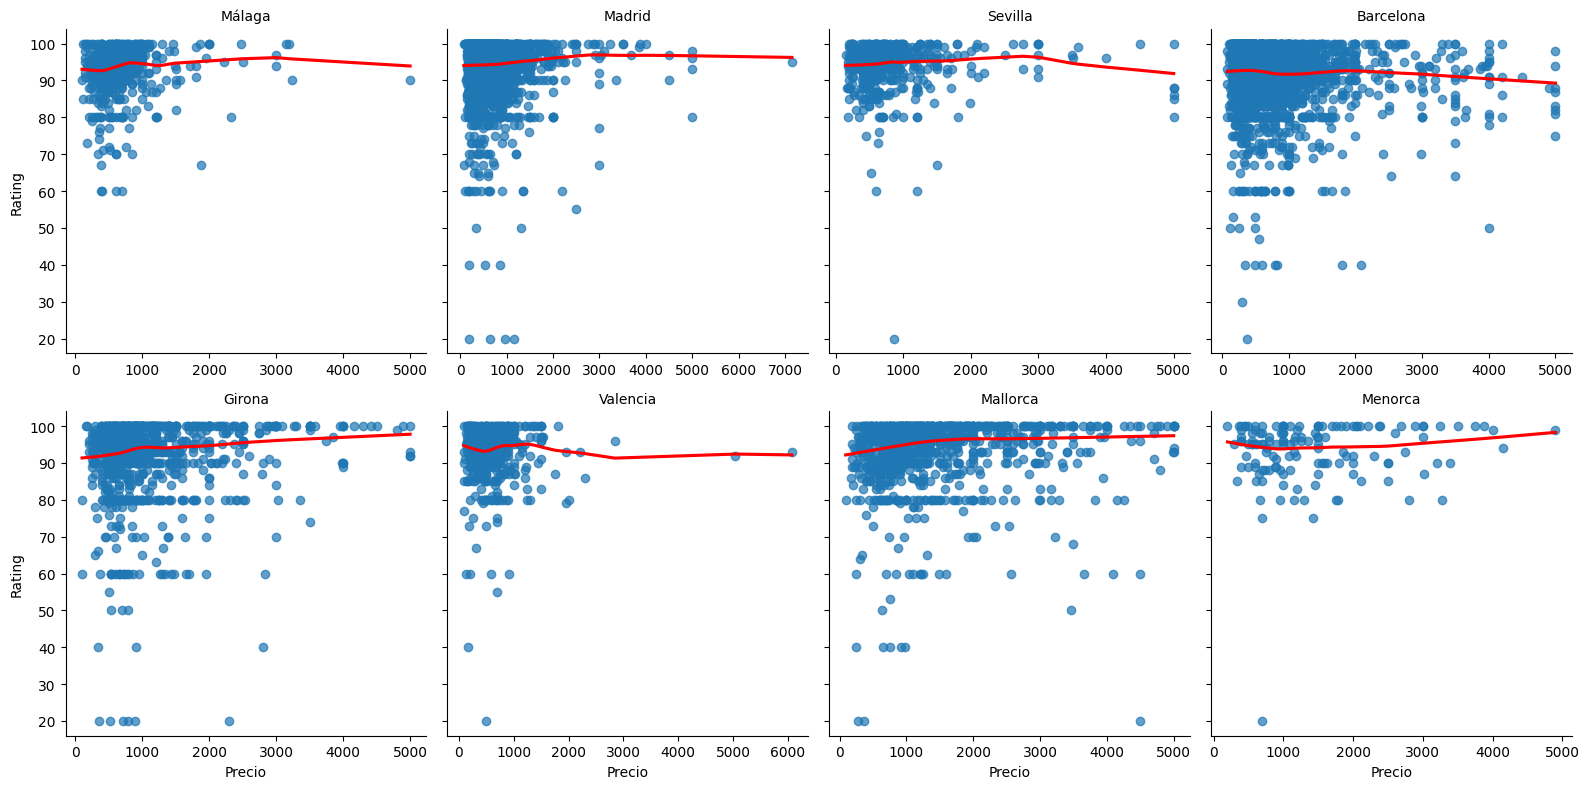

In [124]:
g = sns.FacetGrid(df_clean, col='city', col_wrap=4, height=4, sharex=False, sharey=True)
g.map_dataframe(
    sns.regplot,
    x='price',
    y='review_scores_rating',
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'red'},
    lowess=True 
)
g.set_axis_labels("Precio", "Rating")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

- Barcelona: Tendencia casi plana o ligeramente negativa; pagar más no se asocia con mejor rating de forma consistente.
- Girona: Pendiente más claramente positiva; a mayor precio, el rating tiende a subir modestamente.
- Madrid: Positiva pero muy suave; impacto práctico bajo.
- Mallorca: Positiva y algo más marcada que la media; sugiere relación monótona débil.
- Menorca: Relación poco clara; dispersión alta y línea casi plana.
- Málaga: Ligera positividad; efecto pequeño pero visible.
- Sevilla: Tendencia muy tenue; difícil extraer una señal sólida.
- Valencia: Señal débil; posible efecto techo que aplana la tendencia.

## División de precio por rangos cuartiles:

Límites de los cuantiles de precio:
[  80.  390.  600.  820. 1250. 7143.]


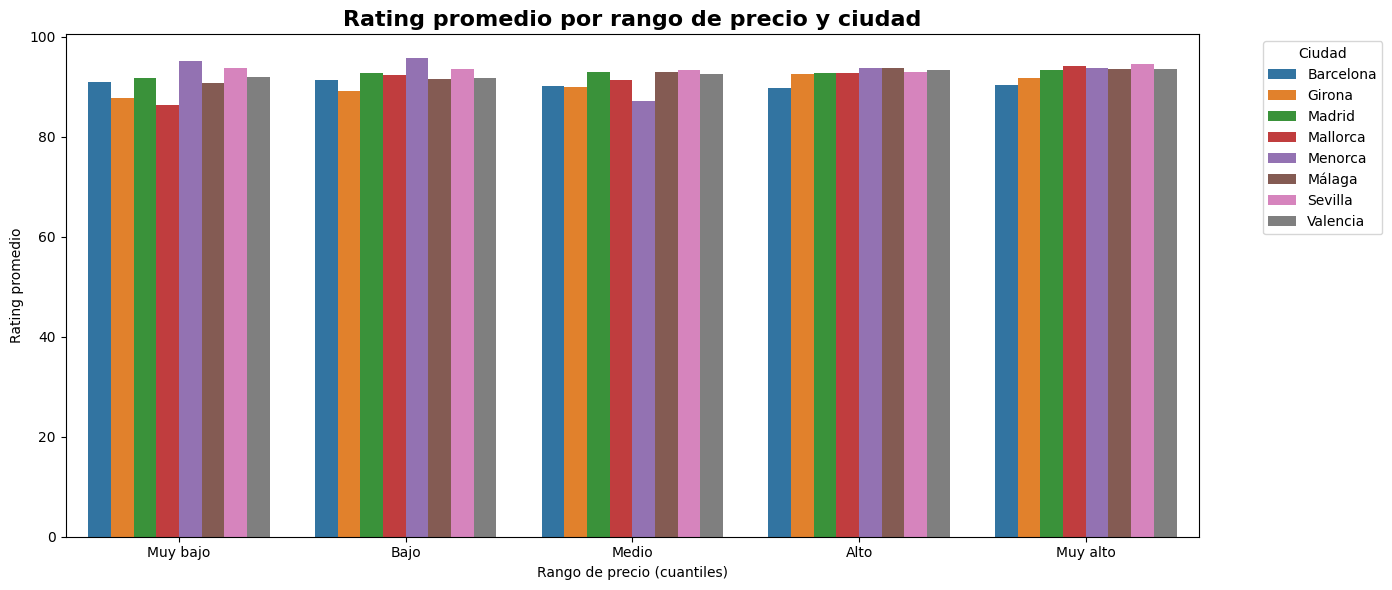


Promedio de rating por rango de precio y ciudad:


,city,price_quantil,mean,count
0,Barcelona,Muy bajo,91.034426,610
1,Barcelona,Bajo,91.285433,508
2,Barcelona,Medio,90.058594,256
3,Barcelona,Alto,89.734870,347
4,Barcelona,Muy alto,90.414201,338
5,Girona,Muy bajo,87.787234,47
6,Girona,Bajo,89.147059,170
7,Girona,Medio,89.984772,197
8,Girona,Alto,92.564655,232
9,Girona,Muy alto,91.820000,250


In [ ]:
# Análisis por cuantiles de precio
# Dividir el precio en 5 grupos
price_quantil, bins = pd.qcut(
    df_clean['price'], 
    q=5, 
    labels=['Muy bajo','Bajo','Medio','Alto','Muy alto'], 
    duplicates='drop', 
    retbins=True
)

print("Límites de los cuantiles de precio:")
print(bins)


# Calcular promedio de rating por rango de precio y ciudad
rating_by_quantil = (
    df_clean.groupby(['city','price_quantil'])['review_scores_rating']
    .agg(['mean','count'])
    .reset_index()
)

# Visualización del rating promedio por rango
plt.figure(figsize=(14,6))
sns.barplot(
    data=rating_by_quantil,
    x='price_quantil', y='mean', hue='city',
    palette='tab10'
)
plt.title("Rating promedio por rango de precio y ciudad", fontsize=16, weight='bold')
plt.xlabel("Rango de precio (cuantiles)")
plt.ylabel("Rating promedio")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Ciudad')
plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\nPromedio de rating por rango de precio y ciudad:")
display(rating_by_quantil)


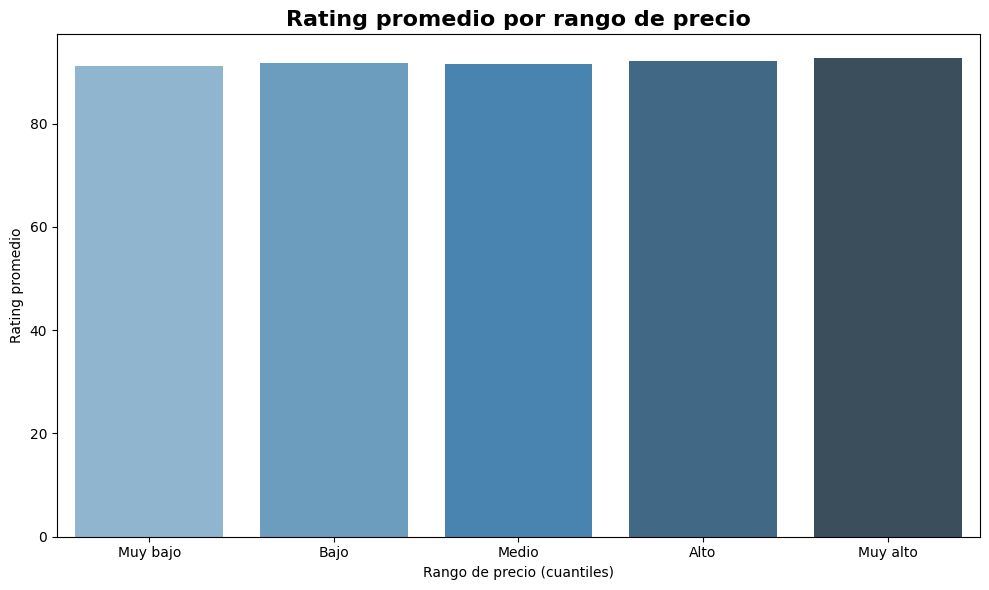


Promedio de rating por rango de precio:


,price_quantil,mean,count
0,Muy bajo,91.200977,1433
1,Bajo,91.779693,1566
2,Medio,91.536670,1159
3,Alto,92.109104,1384
4,Muy alto,92.667878,1376


In [ ]:
rating_by_quantil = (
    df_clean.groupby('price_quantil')['review_scores_rating']
    .agg(['mean', 'count'])
    .reset_index()
)


plt.figure(figsize=(10,6))
sns.barplot(
    data=rating_by_quantil,
    x='price_quantil', y='mean',
    palette='Blues_d'
)
plt.title("Rating promedio por rango de precio", fontsize=16, weight='bold')
plt.xlabel("Rango de precio (cuantiles)")
plt.ylabel("Rating promedio")
plt.tight_layout()
plt.show()


print("\nPromedio de rating por rango de precio:")
display(rating_by_quantil)